# Data Cleaning & Feature Engineering

This notebook walks through every step of the cleaning and feature engineering pipeline, with the actual code and before/after comparisons so you can see exactly what changed and why.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

In [20]:
df_raw = pd.read_excel("../data/raw/E Commerce Dataset.xlsx", sheet_name="E Comm")
print(f"Raw dataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Raw dataset: 5630 rows, 20 columns


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


---
# Part 1: Data Cleaning

## Step 1: Drop CustomerID

CustomerID is a unique identifier with no predictive value. We remove it before modeling.

In [21]:
df = df_raw.copy()
print(f"Before: {df.shape[1]} columns — {df.columns.tolist()[:5]}...")
df = df.drop(columns=["CustomerID"])
print(f"After:  {df.shape[1]} columns — CustomerID removed")

Before: 20 columns — ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier']...
After:  19 columns — CustomerID removed


## Step 2: Merge Duplicate Categories

Several categorical columns have duplicate category names that refer to the same thing:
- `PreferredLoginDevice`: "Phone" → "Mobile Phone"
- `PreferredPaymentMode`: "CC" → "Credit Card", "COD" → "Cash on Delivery"
- `PreferedOrderCat`: "Mobile" → "Mobile Phone"

In [22]:
cat_cols = ["PreferredLoginDevice", "PreferredPaymentMode", "PreferedOrderCat"]

print("=== BEFORE MERGING ===")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())

=== BEFORE MERGING ===

PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149

PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264


In [23]:
# Merge duplicate categories
df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace("Phone", "Mobile Phone")

df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({
    "CC": "Credit Card",
    "COD": "Cash on Delivery",
})

df["PreferedOrderCat"] = df["PreferedOrderCat"].replace("Mobile", "Mobile Phone")

print("=== AFTER MERGING ===")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())

=== AFTER MERGING ===

PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    3996
Computer        1634

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414

PreferedOrderCat:
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264


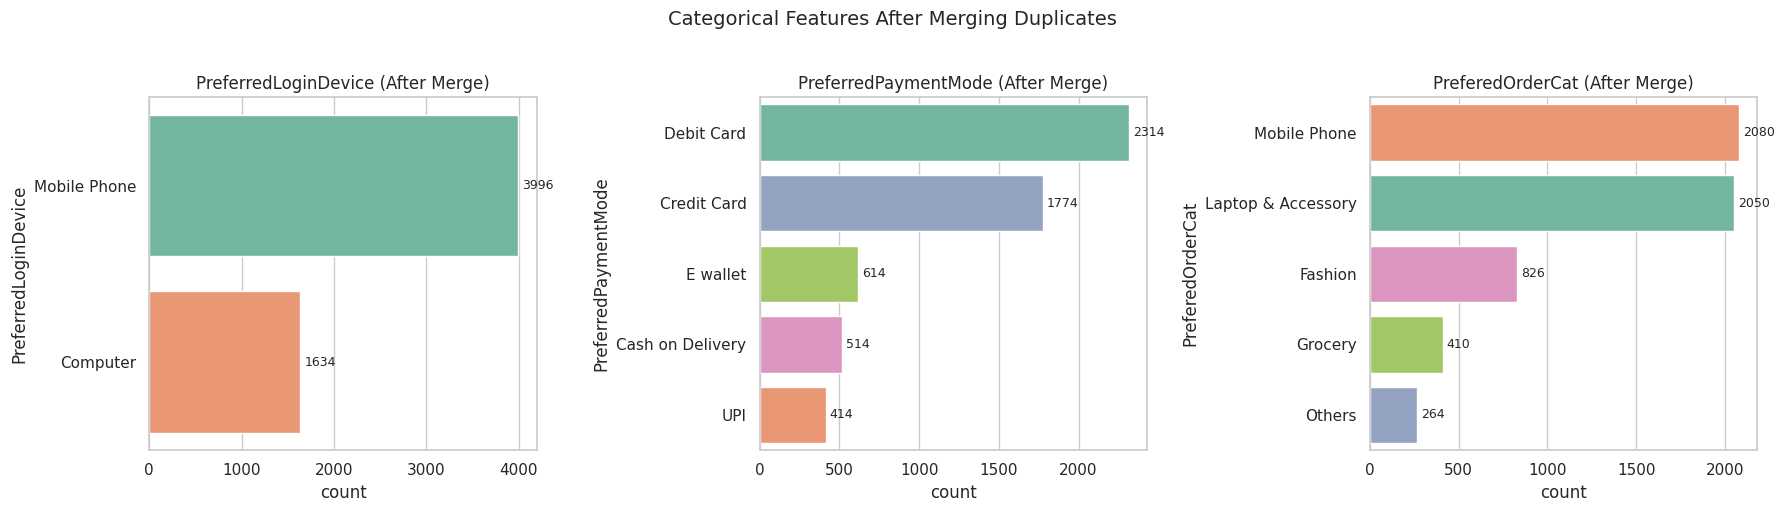

In [24]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, ax=axes[i], order=order, hue=col, palette="Set2")
    axes[i].set_title(f"{col} (After Merge)")
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%d", padding=3, fontsize=9)

plt.suptitle("Categorical Features After Merging Duplicates", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 3: Fix Outliers in WarehouseToHome

Values 126 and 127 are data entry errors — a "1" was prepended. We correct them to 26 and 27.

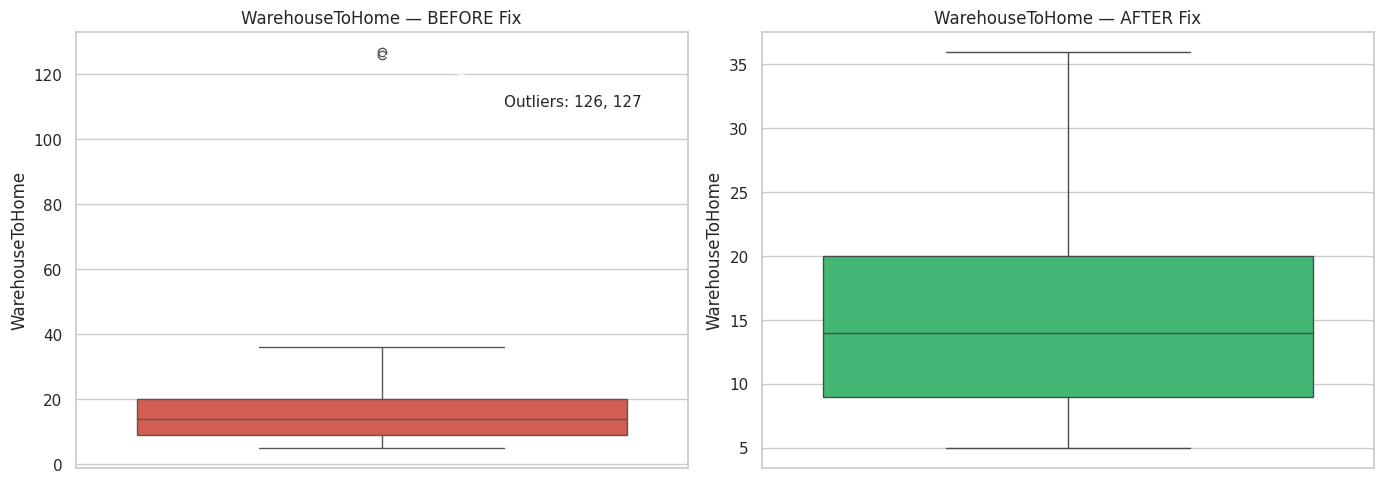

Max value after fix: 36.0
Values >= 100: 0


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
sns.boxplot(y=df["WarehouseToHome"], ax=axes[0], color="#e74c3c")
axes[0].set_title("WarehouseToHome — BEFORE Fix")
axes[0].annotate("Outliers: 126, 127", xy=(0, 126), fontsize=11,
                 arrowprops=dict(arrowstyle="->"), xytext=(0.2, 110))

# Fix outliers: 126 → 26, 127 → 27
df["WarehouseToHome"] = df["WarehouseToHome"].replace({126: 26, 127: 27})

# After
sns.boxplot(y=df["WarehouseToHome"], ax=axes[1], color="#2ecc71")
axes[1].set_title("WarehouseToHome — AFTER Fix")

plt.tight_layout()
plt.show()

print(f"Max value after fix: {df['WarehouseToHome'].max()}")
print(f"Values >= 100: {(df['WarehouseToHome'] >= 100).sum()}")

## Step 4: Impute Missing Values

7 columns have ~4.5-5.5% missing values. We use **median imputation** since most distributions are right-skewed.

In [26]:
cols_with_missing = df.columns[df.isnull().any()].tolist()

# Show missing before
missing_before = df[cols_with_missing].isnull().sum()
print("=== MISSING VALUES BEFORE IMPUTATION ===")
for col in cols_with_missing:
    count = df[col].isnull().sum()
    pct = count / len(df) * 100
    median = df[col].median()
    print(f"  {col}: {count} missing ({pct:.2f}%) — will impute with median = {median}")

=== MISSING VALUES BEFORE IMPUTATION ===
  Tenure: 264 missing (4.69%) — will impute with median = 9.0
  WarehouseToHome: 251 missing (4.46%) — will impute with median = 14.0
  HourSpendOnApp: 255 missing (4.53%) — will impute with median = 3.0
  OrderAmountHikeFromlastYear: 265 missing (4.71%) — will impute with median = 15.0
  CouponUsed: 256 missing (4.55%) — will impute with median = 1.0
  OrderCount: 258 missing (4.58%) — will impute with median = 2.0
  DaySinceLastOrder: 307 missing (5.45%) — will impute with median = 3.0


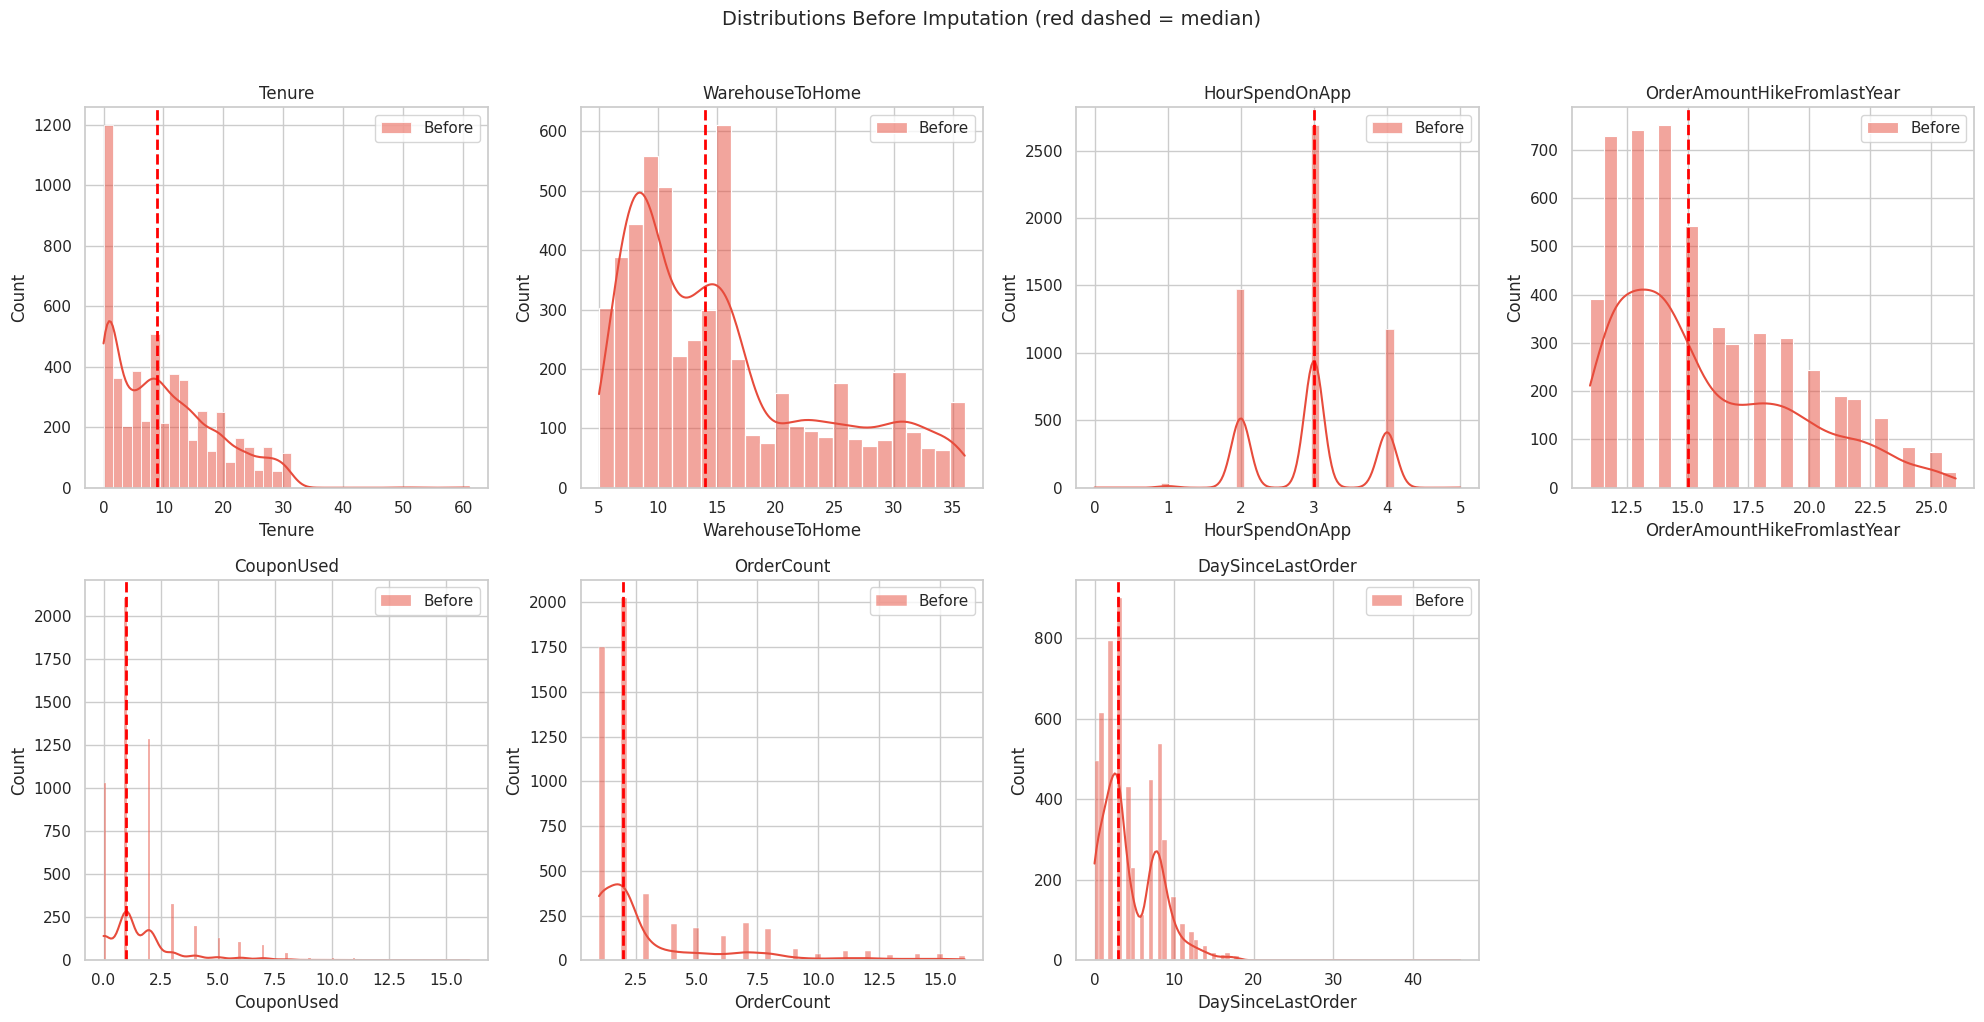

In [27]:
# Before/after distribution comparison
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_with_missing):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color="#e74c3c", label="Before", alpha=0.5)
    axes[i].axvline(df[col].median(), color="red", linestyle="--", linewidth=2)
    axes[i].set_title(f"{col}")
    axes[i].legend()

for j in range(len(cols_with_missing), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions Before Imputation (red dashed = median)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Impute missing values with median
cols_to_impute = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "OrderAmountHikeFromlastYear", "CouponUsed",
    "OrderCount", "DaySinceLastOrder",
]

for col in cols_to_impute:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print("=== AFTER IMPUTATION ===")
print(f"Total missing values: {df.isnull().sum().sum()}")

=== AFTER IMPUTATION ===
Total missing values: 0


## Cleaning Summary

| Step | Action | Impact |
|------|--------|--------|
| 1 | Drop CustomerID | 20 → 19 columns |
| 2 | Merge duplicate categories | 3 columns fixed (Phone→Mobile Phone, CC→Credit Card, COD→Cash on Delivery, Mobile→Mobile Phone) |
| 3 | Fix WarehouseToHome outliers | 126→26, 127→27 |
| 4 | Median imputation | 1,856 missing → 0 |

---
# Part 2: Feature Engineering

## New Features (6 total)

| # | Feature | Formula | Why |
|---|---------|---------|-----|
| 1 | `tenure_bucket` | Bin Tenure into 4 groups | Non-linear tenure-churn relationship |
| 2 | `engagement_score` | HourSpendOnApp × OrderCount | Combines app usage + purchase frequency |
| 3 | `cashback_per_order` | CashbackAmount ÷ OrderCount | Normalized engagement metric |
| 4 | `is_recent_buyer` | 1 if DaySinceLastOrder ≤ 3 | Binary recency flag |
| 5 | `has_multi_device` | 1 if Devices ≥ 4 | Platform investment indicator |
| 6 | `is_high_spender` | 1 if OrderAmountHike > 20% | Spending trajectory flag |

In [29]:
# Feature 1: Tenure bucket
bins = [0, 6, 12, 24, np.inf]
labels = ["new", "settling", "established", "loyal"]
df["tenure_bucket"] = pd.cut(df["Tenure"], bins=bins, labels=labels, include_lowest=True)

# Feature 2: Engagement score (app usage × purchase frequency)
df["engagement_score"] = df["HourSpendOnApp"] * df["OrderCount"]

# Feature 3: Cashback per order (handle division by zero)
df["cashback_per_order"] = np.where(
    df["OrderCount"] > 0,
    df["CashbackAmount"] / df["OrderCount"],
    0,
)

# Feature 4: Is recent buyer (ordered in last 3 days)
df["is_recent_buyer"] = (df["DaySinceLastOrder"] <= 3).astype(int)

# Feature 5: Has multi device (4+ devices registered)
df["has_multi_device"] = (df["NumberOfDeviceRegistered"] >= 4).astype(int)

# Feature 6: Is high spender (order amount hike > 20%)
df["is_high_spender"] = (df["OrderAmountHikeFromlastYear"] > 20).astype(int)

print(f"Columns after feature creation: {df.shape[1]}")
print(f"New columns: {['tenure_bucket', 'engagement_score', 'cashback_per_order', 'is_recent_buyer', 'has_multi_device', 'is_high_spender']}")

Columns after feature creation: 25
New columns: ['tenure_bucket', 'engagement_score', 'cashback_per_order', 'is_recent_buyer', 'has_multi_device', 'is_high_spender']


### Feature 1: Tenure Bucket

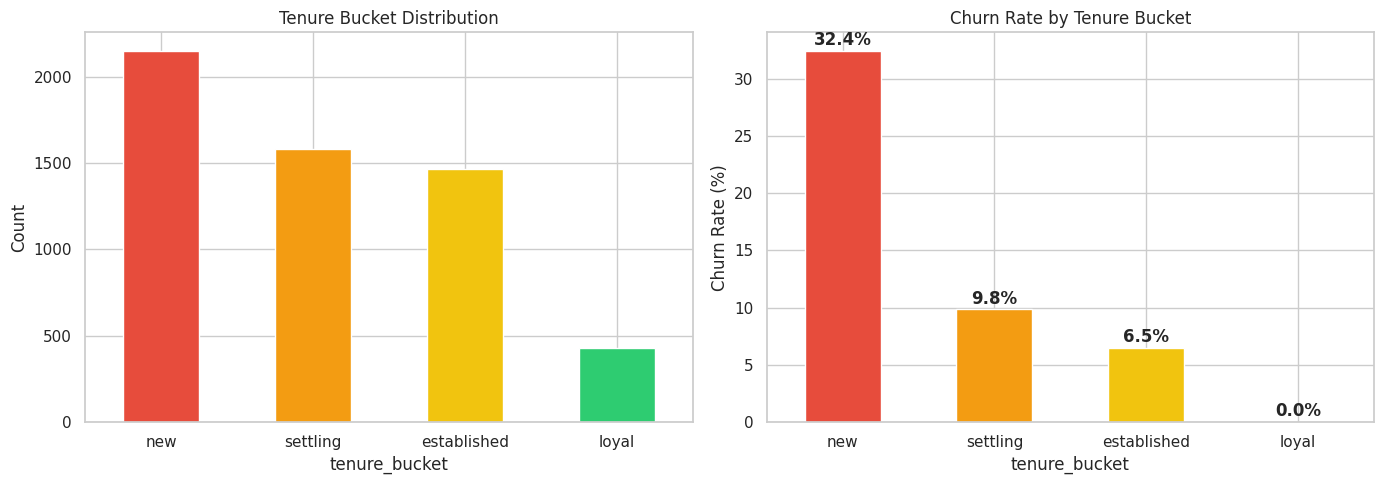

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
df["tenure_bucket"].value_counts().plot(kind="bar", ax=axes[0], color=["#e74c3c", "#f39c12", "#f1c40f", "#2ecc71"])
axes[0].set_title("Tenure Bucket Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Churn rate per bucket
churn_by_bucket = df.groupby("tenure_bucket", observed=True)["Churn"].mean() * 100
churn_by_bucket.plot(kind="bar", ax=axes[1], color=["#e74c3c", "#f39c12", "#f1c40f", "#2ecc71"])
axes[1].set_title("Churn Rate by Tenure Bucket")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=0)
for i, v in enumerate(churn_by_bucket.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Feature 2: Engagement Score & Feature 3: Cashback Per Order

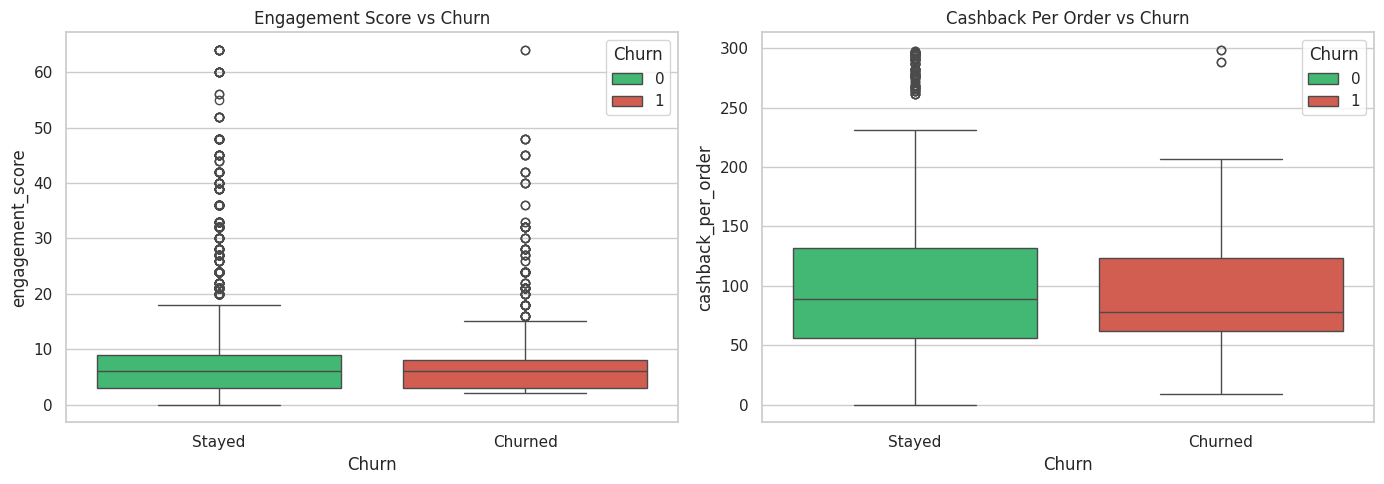

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Engagement score vs Churn
sns.boxplot(x="Churn", y="engagement_score", data=df, ax=axes[0], hue="Churn",
            palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Engagement Score vs Churn")
axes[0].set_xticklabels(["Stayed", "Churned"])

# Cashback per order vs Churn
sns.boxplot(x="Churn", y="cashback_per_order", data=df, ax=axes[1], hue="Churn",
            palette=["#2ecc71", "#e74c3c"])
axes[1].set_title("Cashback Per Order vs Churn")
axes[1].set_xticklabels(["Stayed", "Churned"])

plt.tight_layout()
plt.show()

### Features 4, 5, 6: Binary Flags

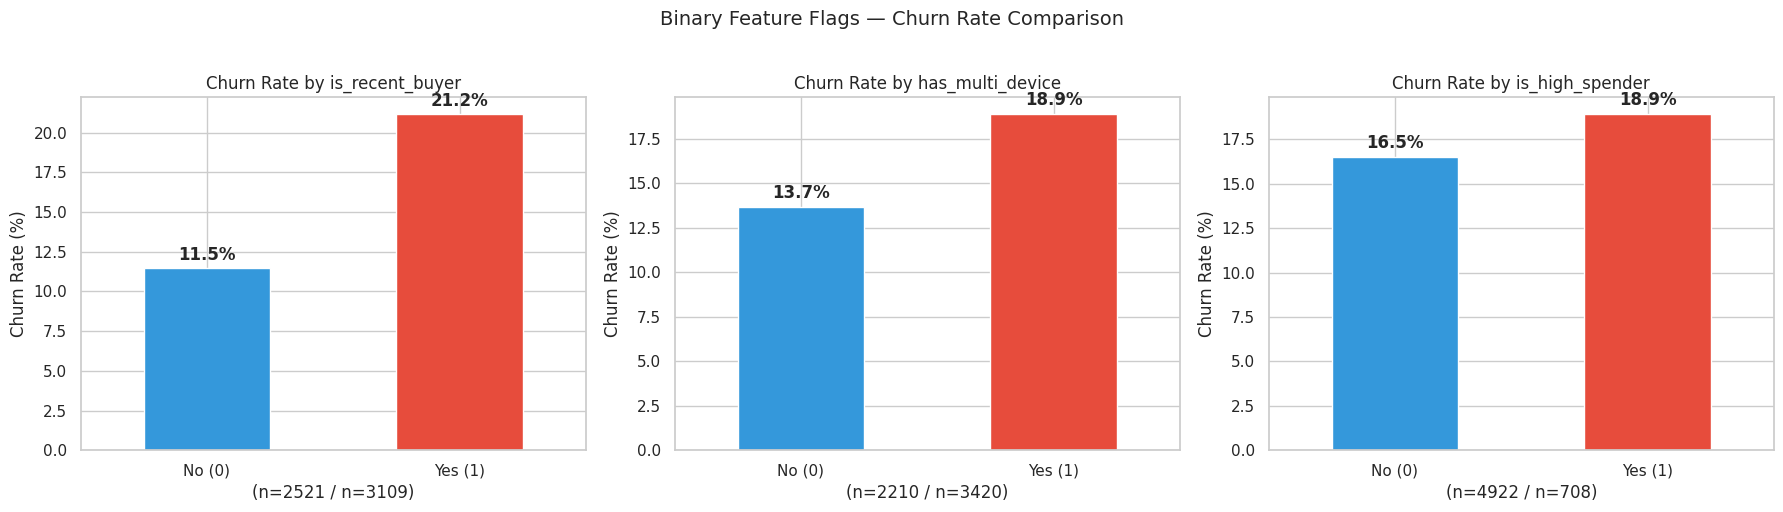

In [32]:
binary_features = ["is_recent_buyer", "has_multi_device", "is_high_spender"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(binary_features):
    # Churn rate for each flag value
    churn_rate = df.groupby(feat)["Churn"].mean() * 100
    churn_rate.plot(kind="bar", ax=axes[i], color=["#3498db", "#e74c3c"])
    axes[i].set_title(f"Churn Rate by {feat}")
    axes[i].set_ylabel("Churn Rate (%)")
    axes[i].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)
    for j, v in enumerate(churn_rate.values):
        axes[i].text(j, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

    # Add counts
    counts = df[feat].value_counts().sort_index()
    axes[i].set_xlabel(f"(n={counts[0]} / n={counts[1]})")

plt.suptitle("Binary Feature Flags — Churn Rate Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Encoding Categorical Variables

- **Label encoding:** Gender (2), MaritalStatus (3), tenure_bucket (4)
- **One-hot encoding:** PreferredLoginDevice, PreferredPaymentMode, PreferedOrderCat (with `drop_first=True` to avoid multicollinearity)

In [33]:
print(f"Columns before encoding: {df.shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include=['object', 'category']).columns.tolist()}")

# Label encoding
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["MaritalStatus"] = df["MaritalStatus"].map({"Single": 0, "Married": 1, "Divorced": 2})
df["tenure_bucket"] = df["tenure_bucket"].map({"new": 0, "settling": 1, "established": 2, "loyal": 3})

# One-hot encoding (drop_first=True to avoid multicollinearity)
ohe_cols = ["PreferredLoginDevice", "PreferredPaymentMode", "PreferedOrderCat"]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

print(f"\nColumns after encoding: {df.shape[1]}")
print(f"Categorical columns remaining: {df.select_dtypes(include=['object', 'category']).columns.tolist()}")
print(f"\nAll columns:\n{df.columns.tolist()}")

Columns before encoding: 25
Categorical columns: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus', 'tenure_bucket']

Columns after encoding: 31
Categorical columns remaining: ['tenure_bucket']

All columns:
['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'tenure_bucket', 'engagement_score', 'cashback_per_order', 'is_recent_buyer', 'has_multi_device', 'is_high_spender', 'PreferredLoginDevice_Mobile Phone', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others']


In [34]:
df.head(10)

,Churn,Tenure,CityTier,WarehouseToHome,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,MaritalStatus,NumberOfAddress,...,is_high_spender,PreferredLoginDevice_Mobile Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others
0,1,4.0,3,6.0,1,3.0,3,2,0,9,...,0,1,0,1,0,0,0,1,0,0
1,1,9.0,1,8.0,0,3.0,4,3,0,7,...,0,1,0,0,0,1,0,0,1,0
2,1,9.0,1,30.0,0,2.0,4,3,0,6,...,0,1,0,1,0,0,0,0,1,0
3,1,0.0,3,15.0,0,2.0,4,5,0,8,...,1,1,0,1,0,0,0,1,0,0
4,1,0.0,1,12.0,0,3.0,3,5,0,3,...,0,1,1,0,0,0,0,0,1,0
5,1,0.0,1,22.0,1,3.0,5,5,0,2,...,1,0,0,1,0,0,0,0,1,0
6,1,9.0,3,11.0,0,2.0,3,2,2,4,...,0,1,0,0,0,0,0,1,0,0
7,1,9.0,1,6.0,0,3.0,3,2,2,3,...,0,1,1,0,0,0,0,0,1,0
8,1,13.0,3,9.0,0,3.0,4,3,2,2,...,0,1,0,0,1,0,0,0,1,0
9,1,9.0,1,31.0,0,2.0,5,3,0,2,...,0,1,0,1,0,0,0,0,1,0


## Correlation of New Features with Churn

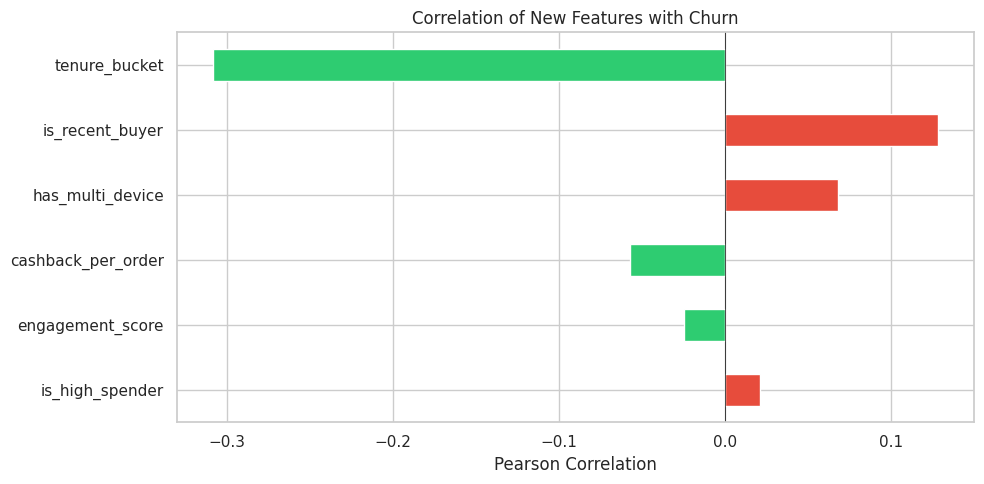

In [35]:
new_features = ["tenure_bucket", "engagement_score", "cashback_per_order",
                "is_recent_buyer", "has_multi_device", "is_high_spender"]

churn_corr = df[new_features + ["Churn"]].corr()["Churn"].drop("Churn").sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
churn_corr.plot(kind="barh", ax=ax, color=churn_corr.apply(lambda x: "#e74c3c" if x > 0 else "#2ecc71"))
ax.set_title("Correlation of New Features with Churn")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

## Final Result — Save Processed Data

In [36]:
print(f"Final dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Dtypes:\n{df.dtypes.value_counts()}")

df.to_csv("../data/processed/engineered.csv", index=False)
print("\nSaved to data/processed/engineered.csv — Ready for modeling!")
df.head()

Final dataset: 5630 rows, 31 columns
Missing values: 0
Dtypes:
int64       20
float64     10
category     1
Name: count, dtype: int64

Saved to data/processed/engineered.csv — Ready for modeling!


,Churn,Tenure,CityTier,WarehouseToHome,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,MaritalStatus,NumberOfAddress,...,is_high_spender,PreferredLoginDevice_Mobile Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others
0,1,4.0,3,6.0,1,3.0,3,2,0,9,...,0,1,0,1,0,0,0,1,0,0
1,1,9.0,1,8.0,0,3.0,4,3,0,7,...,0,1,0,0,0,1,0,0,1,0
2,1,9.0,1,30.0,0,2.0,4,3,0,6,...,0,1,0,1,0,0,0,0,1,0
3,1,0.0,3,15.0,0,2.0,4,5,0,8,...,1,1,0,1,0,0,0,1,0,0
4,1,0.0,1,12.0,0,3.0,3,5,0,3,...,0,1,1,0,0,0,0,0,1,0
